In [1]:
# IMPORT LIBRARIES
import numpy as np
import pandas as pd
import os
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)



c:\Users\Dilsh\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [4]:

X_test = joblib.load("../Models/x_test.pkl")
y_test = joblib.load("../Models/y_test.pkl")

print("X_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)


X_test Shape : (125932, 13)
y_test Shape : (125932,)


In [6]:
folder_path = "../Models/with_out_pca_models"
model_list = []

for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        model = joblib.load(os.path.join(folder_path, file))
        # check if it is a model
        if hasattr(model, "predict"):
            model_list.append({
                "Model_Name": file.replace(".pkl", ""),
                "Model_Object": model
            })

# check loaded models
for m in model_list:
    print(m["Model_Name"])

df_models = pd.DataFrame(model_list)

CatBoost_model
DecisionTree_model
LightGBM_model
Logistic_model
NaiveBayes_model
RandomForest_model
SVM_model


In [7]:
results = []

for i, row in df_models.iterrows():

    model = row["Model_Object"]
    name = row["Model_Name"]

    # Prediction
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1_Score": f1
    })

# Results DataFrame
results_df = pd.DataFrame(results)

# Sort by F1 Score
results_df = results_df.sort_values(
    by="F1_Score",
    ascending=False,
    ignore_index=True
)



In [ ]:
print("\nMODEL RESULTS")
print(results_df)


MODEL RESULTS
                Model  Accuracy  Precision    Recall  F1_Score
0      CatBoost_model  0.889901   0.883403  0.869183  0.876235
1      LightGBM_model  0.889226   0.882013  0.869236  0.875578
2  RandomForest_model  0.885764   0.880984  0.861638  0.871204
3      Logistic_model  0.884088   0.879534  0.859177  0.869236
4           SVM_model  0.883850   0.880186  0.857725  0.868810
5  DecisionTree_model  0.882135   0.876526  0.858008  0.867168
6    NaiveBayes_model  0.872082   0.856875  0.858043  0.857459


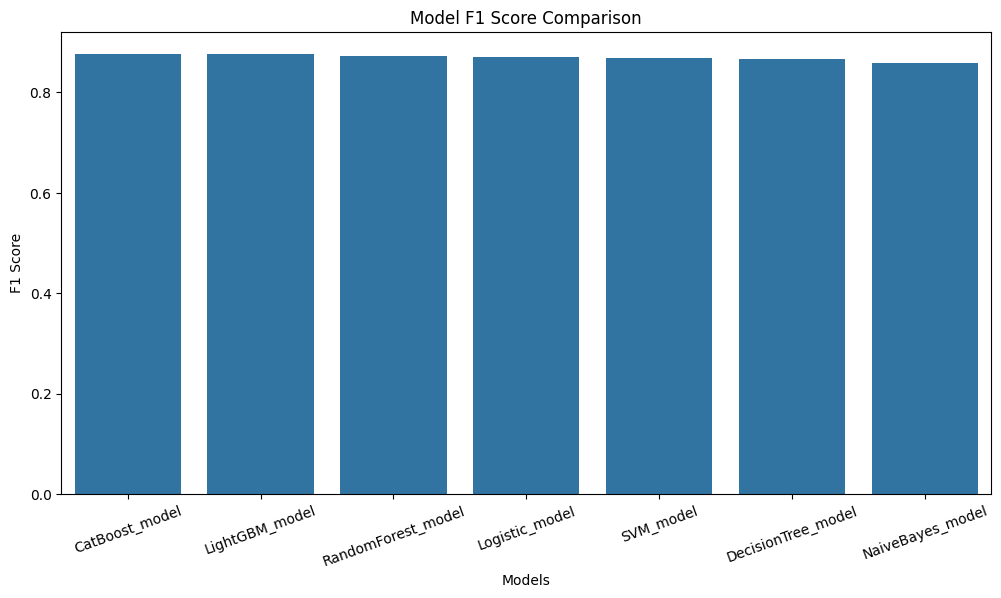

In [9]:

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1_Score"
)

plt.title("Model F1 Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1 Score")

plt.xticks(rotation=20)

plt.show()



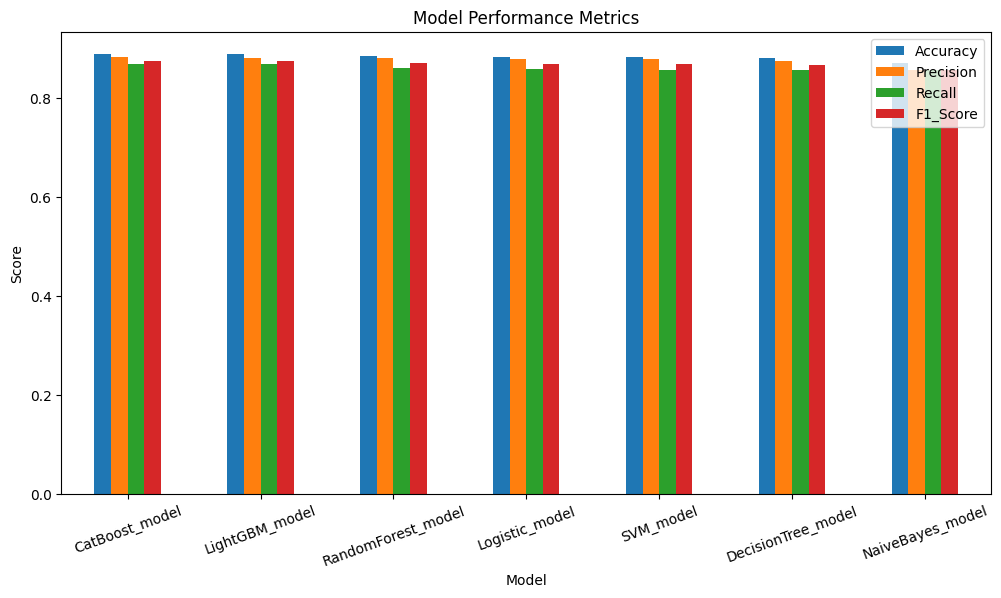

In [10]:
metrics_df = results_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1_Score"]
]

metrics_df.set_index("Model").plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Model Performance Metrics")
plt.ylabel("Score")

plt.xticks(rotation=20)

plt.show()


In [11]:
best_model_name = results_df.iloc[0]["Model"]

print("\nBEST MODEL :", best_model_name)

# Create model dictionary
best_models = {
    row["Model_Name"]: row["Model_Object"]
    for idx, row in df_models.iterrows()
}

best_model = best_models[best_model_name]



BEST MODEL : CatBoost_model


In [12]:
y_pred = best_model.predict(X_test)


acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nFINAL METRICS")
print("Accuracy :", round(acc,4))
print("Precision:", round(prec,4))
print("Recall   :", round(rec,4))
print("F1 Score :", round(f1,4))



FINAL METRICS
Accuracy : 0.8899
Precision: 0.8834
Recall   : 0.8692
F1 Score : 0.8762


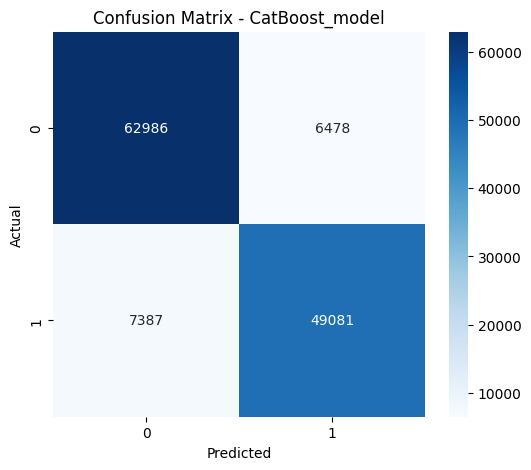

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(f"Confusion Matrix - {best_model_name}")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()



In [14]:
print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))



CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.90      0.91      0.90     69464
           1       0.88      0.87      0.88     56468

    accuracy                           0.89    125932
   macro avg       0.89      0.89      0.89    125932
weighted avg       0.89      0.89      0.89    125932



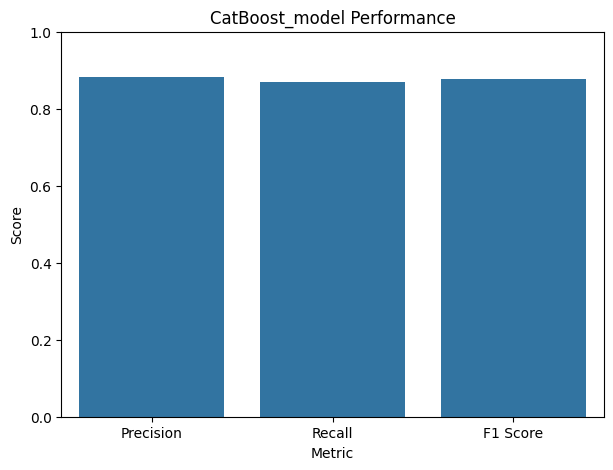

In [15]:
final_metrics = pd.DataFrame({

    "Metric": [
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Score": [
        prec,
        rec,
        f1
    ]
})

plt.figure(figsize=(7,5))

sns.barplot(
    data=final_metrics,
    x="Metric",
    y="Score"
)

plt.title(f"{best_model_name} Performance")

plt.ylim(0,1)

plt.show()


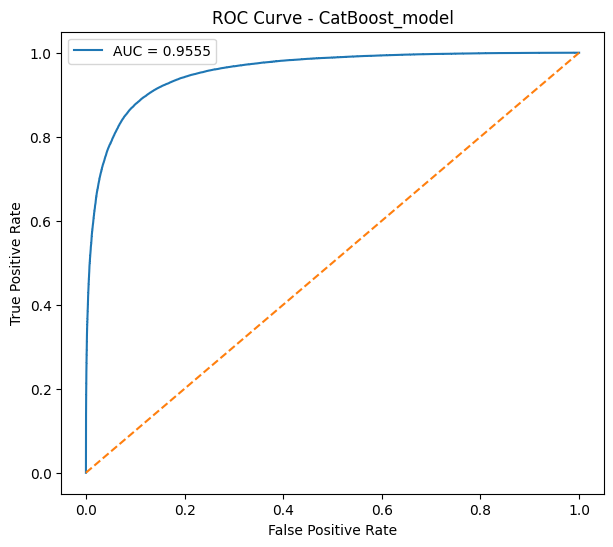

In [16]:
# ROC CURVE

if hasattr(best_model, "predict_proba"):

    prob = best_model.predict_proba(X_test)[:,1]

else:

    prob = best_model.decision_function(X_test)

# ROC
fpr, tpr, thresholds = roc_curve(
    y_test,
    prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(f"ROC Curve - {best_model_name}")

plt.legend()

plt.show()
